# Elevation Analysis - GMTED2010 Dataset

## Analysis Structure

**Section 0: Setup & Imports**
- Configure multi-threading
- Import required libraries
- Define helper functions

**Section 1: Initial Data Loading**
- Load ESRI Grid raster (elevation data)
- Display dataset summary
- Quick initial assessment

**Section 2: Spatial Operations & Feature Extraction**
- Load fire point locations
- Create bounding box with buffer
- Clip raster to fire locations
- Extract elevation values at fire coordinates
- Compute derived features (slope, aspect, roughness)
- Visualize clipped raster with fire overlay

**Section 3: Exploratory Data Analysis (Raw Data)**
- Descriptive statistics (raw values)
- Univariate analysis (histograms, boxplots, Q-Q plots)
- Bivariate analysis (scatter plots, correlation heatmap)
- Fire vs terrain relationship (raw values)

**Section 4: Data Preprocessing**
- Check and remove duplicates
- Handle outliers (IQR method)
- Normalize features (StandardScaler)
- Validate preprocessing results

**Section 5: Save Results**
- Save elevation features with fire data
- Save clipped raster
- Generate summary report

---
## Section 0: Setup & Imports

In [1]:
import os
import multiprocessing

def configure_threading(max_threads=None):
    """Set thread env variables so numeric libs leverage multiple CPU cores."""
    if max_threads is None:
        max_threads = multiprocessing.cpu_count()
    thread_env_vars = [
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ]
    for var in thread_env_vars:
        os.environ[var] = str(max_threads)
    print(f"Threading configured to use up to {max_threads} CPU cores.")

configure_threading()

Threading configured to use up to 12 CPU cores.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio as rio
from rasterio.plot import plotting_extent
from rasterio.transform import rowcol
from pathlib import Path
from shapely.geometry import box
from affine import Affine
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import generic_gradient_magnitude
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [3]:
# Helper functions to compute terrain features
def compute_slope(elevation_array, cell_size=450):
    """
    Compute slope in degrees from elevation raster.
    cell_size: approximate cell size in meters (~450m for 15 arc-seconds)
    """
    # Compute gradients in x and y directions
    dy, dx = np.gradient(elevation_array, cell_size)
    slope = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi)
    return slope

def compute_aspect(elevation_array):
    """
    Compute aspect (orientation) in degrees from elevation raster.
    0° = North, 90° = East, 180° = South, 270° = West
    """
    dy, dx = np.gradient(elevation_array)
    aspect = np.arctan2(-dy, dx) * (180 / np.pi)
    aspect = (90 - aspect) % 360  # Convert to compass bearing
    return aspect

def compute_roughness(elevation_array):
    """
    Compute terrain roughness index (TRI).
    Measures the difference between center cell and surrounding cells.
    """
    from scipy.ndimage import generic_filter
    
    def tri_kernel(values):
        center = values[len(values)//2]
        return np.sqrt(np.mean((values - center)**2))
    
    roughness = generic_filter(elevation_array, tri_kernel, size=3, mode='nearest')
    return roughness

---
## Section 1: Initial Data Loading

Load the GMTED2010 elevation raster and perform initial assessment.

### 1.1 Load ESRI Grid Raster (Elevation Data)

**GMTED2010 Dataset:**
- Resolution: 15 arc-seconds (~450m at equator)
- CRS: WGS84 (EPSG:4326)
- Coverage: Global (-180° to 180°, -56° to 84°)
- NoData: -32768
- Elevation range: -872m to 8,747m

In [4]:
# Load the GMTED2010 elevation raster (ESRI Grid format)
raster_path = '../dataset/elevation_dataset/be15_grd'

try:
    with rio.open(raster_path) as src:
        raster_data = src.read()  # Read all bands
        raster_profile = src.profile
        raster_bounds = src.bounds
        raster_crs = src.crs
        raster_nodata = src.nodata
        
        print('✓ Elevation raster loaded successfully!')
        print(f'  Number of bands: {raster_data.shape[0]}')
        print(f'  Raster shape: {raster_data.shape[1]} x {raster_data.shape[2]} pixels')
        print(f'  Bounds: {raster_bounds}')
        print(f'  CRS: {raster_crs}')
        print(f'  NoData value: {raster_nodata}')
        print(f'  Memory: {raster_data.nbytes / (1024**3):.2f} GB')
        
except Exception as e:
    print(f'Error loading raster: {e}')

✓ Elevation raster loaded successfully!
  Number of bands: 1
  Raster shape: 33600 x 86400 pixels
  Bounds: BoundingBox(left=-180.00013888888893, bottom=-56.00013888888891, right=179.99986111111085, top=83.999861111111)
  CRS: EPSG:4326
  NoData value: -32768.0
  Memory: 5.41 GB


### 1.2 Dataset Summary & Quick Assessment

In [5]:
# Dataset Content Summary
print("=" * 60)
print("GMTED2010 ELEVATION DATASET SUMMARY")
print("=" * 60)

print(f"\nSpatial Data (Raster):")
print(f"  Dimensions: {raster_data.shape[1]} x {raster_data.shape[2]} pixels")
print(f"  Total pixels: {raster_data.shape[1] * raster_data.shape[2]:,}")
print(f"  Resolution: ~15 arc-seconds (~450m at equator)")
print(f"  Memory: {raster_data.nbytes / (1024**3):.2f} GB")

print("\n" + "=" * 60)

# Quick assessment of elevation values
print("\nQUICK DATA ASSESSMENT")
print("=" * 60)

# Get elevation band (band 1)
elevation_band = raster_data[0]

# Create mask for valid data (exclude NoData)
if raster_nodata is not None:
    valid_mask = elevation_band != raster_nodata
    valid_elevations = elevation_band[valid_mask]
else:
    valid_elevations = elevation_band.flatten()

# print(f"\n1. Elevation Statistics:")
# print(f"  Min elevation: {valid_elevations.min():.2f} m")
# print(f"  Max elevation: {valid_elevations.max():.2f} m")
# print(f"  Mean elevation: {valid_elevations.mean():.2f} m")
# print(f"  Median elevation: {np.percentile(valid_elevations, 50):.2f} m")
# print(f"  Std deviation: {valid_elevations.std():.2f} m")

# print(f"\n2. Data Quality:")
# print(f"  Valid pixels: {valid_elevations.size:,} ({valid_elevations.size/elevation_band.size*100:.2f}%)")
# print(f"  NoData pixels: {elevation_band.size - valid_elevations.size:,}")

# print("\n✓ Initial data loading and assessment complete!")
# print("=" * 60)

GMTED2010 ELEVATION DATASET SUMMARY

Spatial Data (Raster):
  Dimensions: 33600 x 86400 pixels
  Total pixels: 2,903,040,000
  Resolution: ~15 arc-seconds (~450m at equator)
  Memory: 5.41 GB


QUICK DATA ASSESSMENT


---
## Section 2: Spatial Operations & Feature Extraction

### 2.1 Load Fire Point Locations

In [6]:
# Load fire point locations
fires_path = '../results/fires.csv'
fires_df = pd.read_csv(fires_path)

print(f"✓ Loaded {len(fires_df)} fire points")
print(f"  Columns: {list(fires_df.columns)}")
print(f"  Coordinate range:")
print(f"    Longitude: [{fires_df['longitude'].min():.4f}, {fires_df['longitude'].max():.4f}]")
print(f"    Latitude: [{fires_df['latitude'].min():.4f}, {fires_df['latitude'].max():.4f}]")

# Create GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude),
    crs='EPSG:4326'
)
print(f"✓ GeoDataFrame created with {len(fires_gdf)} points")

✓ Loaded 8212 fire points
  Columns: ['longitude', 'latitude', 'class']
  Coordinate range:
    Longitude: [-2.1811, 11.1104]
    Latitude: [33.0164, 37.3235]
✓ GeoDataFrame created with 8212 points


### 2.2 Clip Raster to Fire Point Extent

In [7]:
# Create bounding box with buffer (0.1 degree ~11km)
bbox = fires_gdf.total_bounds  # [minx, miny, maxx, maxy]
buffer = 0.1
bbox_buffered = [bbox[0]-buffer, bbox[1]-buffer, bbox[2]+buffer, bbox[3]+buffer]

print(f"✓ Fire points bounding box (with {buffer}° buffer):")
print(f"  Longitude: [{bbox_buffered[0]:.4f}, {bbox_buffered[2]:.4f}]")
print(f"  Latitude: [{bbox_buffered[1]:.4f}, {bbox_buffered[3]:.4f}]")

# Clip raster to fire point extent
print("\n✓ Clipping raster to fire point extent...")

src_transform = raster_profile['transform']

# Get pixel coordinates for bounding box
row_start, col_start = rowcol(src_transform, bbox_buffered[0], bbox_buffered[3])  # top-left
row_end, col_end = rowcol(src_transform, bbox_buffered[2], bbox_buffered[1])      # bottom-right

# Ensure valid pixel ranges
row_start, row_end = sorted([row_start, row_end])
col_start, col_end = sorted([col_start, col_end])

# Clip to raster bounds
height, width = raster_data.shape[1], raster_data.shape[2]
row_start = max(0, min(row_start, height-1))
row_end = max(0, min(row_end, height-1))
col_start = max(0, min(col_start, width-1))
col_end = max(0, min(col_end, width-1))

# Slice the in-memory array
clipped_array = raster_data[:, row_start:row_end+1, col_start:col_end+1].copy()

# Calculate new transform
new_transform = src_transform * Affine.translation(col_start, row_start)

# Update profile
clipped_profile = raster_profile.copy()
clipped_profile.update({
    'height': clipped_array.shape[1],
    'width': clipped_array.shape[2],
    'transform': new_transform
})

print(f"✓ Raster clipped successfully!")
print(f"  Original: {raster_data.shape[1]} x {raster_data.shape[2]} pixels")
print(f"  Clipped: {clipped_array.shape[1]} x {clipped_array.shape[2]} pixels")
print(f"  Size reduction: {(1 - (clipped_array.size / raster_data.size)) * 100:.1f}%")
print(f"  Memory: {clipped_array.nbytes / (1024**2):.2f} MB")

✓ Fire points bounding box (with 0.1° buffer):
  Longitude: [-2.2811, 11.2104]
  Latitude: [32.9164, 37.4235]

✓ Clipping raster to fire point extent...
✓ Raster clipped successfully!
  Original: 33600 x 86400 pixels
  Clipped: 1083 x 3239 pixels
  Size reduction: 99.9%
  Memory: 6.69 MB


### 2.3 Extract Elevation Values at Fire Locations

In [8]:
# Extract elevation values at exact fire point locations
print("✓ Extracting elevation values at fire point locations...")

elevation_values = []
for idx, point in enumerate(fires_gdf.geometry):
    lon, lat = point.x, point.y
    
    # Convert geographic coordinates to pixel coordinates
    row, col = rowcol(new_transform, lon, lat)
    
    # Check if pixel is within clipped raster bounds
    if 0 <= row < clipped_array.shape[1] and 0 <= col < clipped_array.shape[2]:
        elevation = clipped_array[0, row, col]  # Band 1 contains elevation
        
        # Check if valid (not NoData)
        if raster_nodata is not None and elevation == raster_nodata:
            elevation_values.append(np.nan)
        else:
            elevation_values.append(elevation)
    else:
        elevation_values.append(np.nan)

# Add elevation to fire dataframe
fires_df['elevation'] = elevation_values

print(f"✓ Extraction complete!")
print(f"  Total fire points: {len(fires_df)}")
print(f"  Valid elevation values: {fires_df['elevation'].notna().sum()}")
print(f"  Missing elevation values: {fires_df['elevation'].isna().sum()}")
print(f"  Elevation range: [{fires_df['elevation'].min():.2f}, {fires_df['elevation'].max():.2f}] m")

# Show sample
print("\nSample:")
print(fires_df[['longitude', 'latitude', 'class', 'elevation']].head(10))

✓ Extracting elevation values at fire point locations...
✓ Extraction complete!
  Total fire points: 8212
  Valid elevation values: 8212
  Missing elevation values: 0
  Elevation range: [-30.00, 1991.00] m

Sample:
   longitude  latitude  class  elevation
0    9.42603  37.00734      1        456
1    0.84846  36.48433      0          0
2    4.13116  36.62614      1        222
3    7.28408  36.89190      1         20
4    8.46453  35.31460      0        868
5    4.65055  36.84538      0        336
6    5.36770  37.17534      0          0
7    1.42549  36.16594      0        316
8    4.11798  33.48140      0        631
9    0.87602  36.50915      0          0


### 2.4 Visualize Clipped Raster with Fire Points

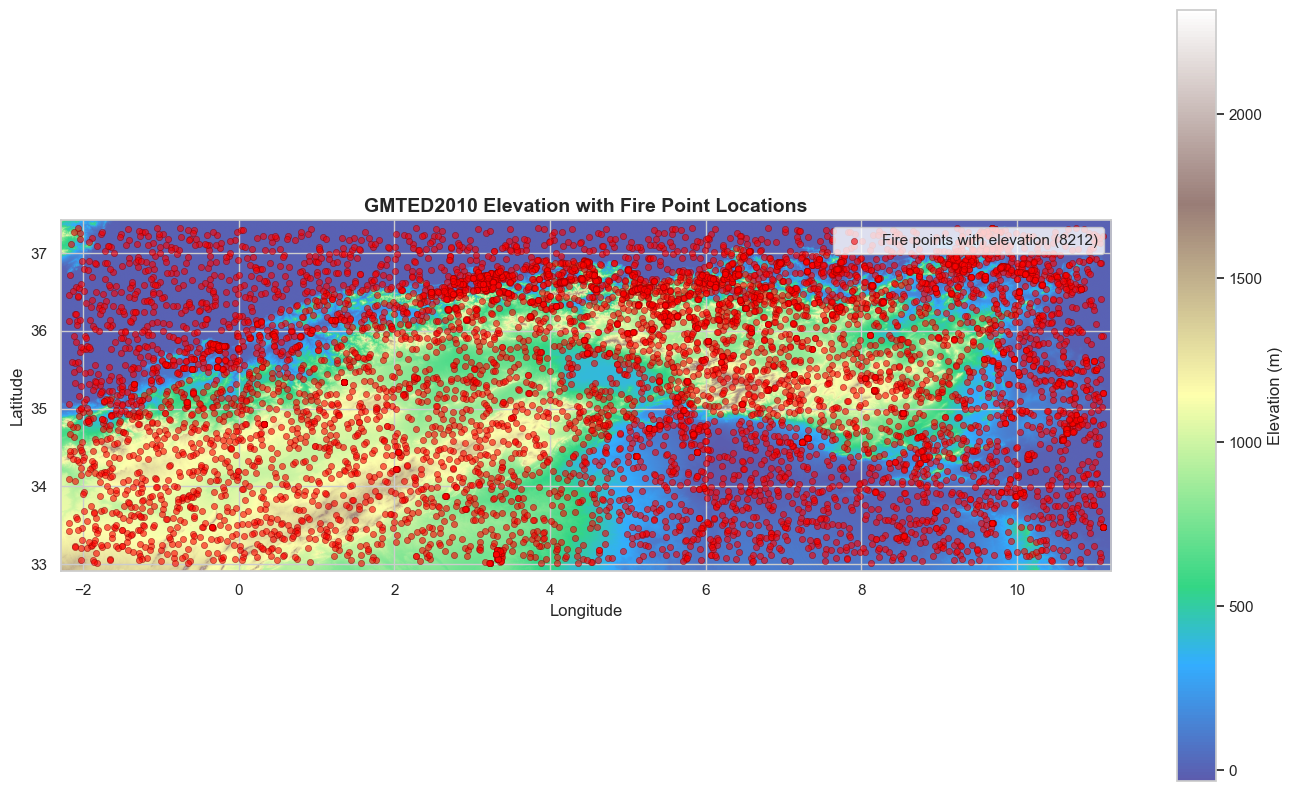

✓ Visualization complete!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot clipped elevation raster
band1 = clipped_array[0].astype('float32')
if raster_nodata is not None:
    band1[band1 == raster_nodata] = np.nan

extent = plotting_extent(band1, transform=new_transform)
im = ax.imshow(band1, cmap='terrain', extent=extent, origin='upper', alpha=0.8)

# Overlay fire points
fires_with_elev = fires_df[fires_df['elevation'].notna()]
fires_without_elev = fires_df[fires_df['elevation'].isna()]

ax.scatter(fires_with_elev['longitude'], fires_with_elev['latitude'], 
           c='red', s=20, alpha=0.6, edgecolors='darkred', linewidth=0.5,
           label=f'Fire points with elevation ({len(fires_with_elev)})')

if len(fires_without_elev) > 0:
    ax.scatter(fires_without_elev['longitude'], fires_without_elev['latitude'], 
               c='orange', s=20, alpha=0.6, marker='x',
               label=f'Fire points without elevation ({len(fires_without_elev)})')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('GMTED2010 Elevation with Fire Point Locations', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
fig.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
plt.tight_layout()
plt.show()

print(f"✓ Visualization complete!")

### 2.5 Compute Derived Terrain Features

In [10]:
print("="*60)
print("TERRAIN FEATURE COMPUTATION")
print("="*60)

# Get elevation band (replace NoData with NaN for computation)
elevation = clipped_array[0].astype('float32')
if raster_nodata is not None:
    elevation[elevation == raster_nodata] = np.nan

print("\n1. Computing Slope...")
slope = compute_slope(elevation, cell_size=450)
print(f"  ✓ Slope computed (range: {np.nanmin(slope):.2f}° to {np.nanmax(slope):.2f}°)")

print("\n2. Computing Aspect...")
aspect = compute_aspect(elevation)
print(f"  ✓ Aspect computed (range: {np.nanmin(aspect):.2f}° to {np.nanmax(aspect):.2f}°)")

print("\n3. Computing Terrain Roughness...")
roughness = compute_roughness(elevation)
print(f"  ✓ Roughness computed (range: {np.nanmin(roughness):.2f} to {np.nanmax(roughness):.2f})")

print("\n✓ All terrain features computed successfully!")
print("="*60)

TERRAIN FEATURE COMPUTATION

1. Computing Slope...
  ✓ Slope computed (range: 0.00° to 53.09°)

2. Computing Aspect...
  ✓ Aspect computed (range: 0.00° to 359.89°)

3. Computing Terrain Roughness...
  ✓ Roughness computed (range: 0.00 to 504.23)

✓ All terrain features computed successfully!


### 2.6 Extract Terrain Features at Fire Locations

In [ ]:
print("="*60)
print("EXTRACTING TERRAIN FEATURES AT FIRE LOCATIONS")
print("="*60)

slope_values = []
aspect_values = []
roughness_values = []

for idx, point in enumerate(fires_gdf.geometry):
    lon, lat = point.x, point.y
    row, col = rowcol(new_transform, lon, lat)
    
    if 0 <= row < slope.shape[0] and 0 <= col < slope.shape[1]:
        slope_values.append(slope[row, col])
        aspect_values.append(aspect[row, col])
        roughness_values.append(roughness[row, col])
    else:
        slope_values.append(np.nan)
        aspect_values.append(np.nan)
        roughness_values.append(np.nan)

# Add to dataframe
fires_df['slope'] = slope_values
fires_df['aspect'] = aspect_values
fires_df['roughness'] = roughness_values

# Keep only records with complete terrain data for analysis
terrain_features = ['elevation', 'slope', 'aspect', 'roughness']
fires_raw = fires_df[fires_df[terrain_features].notna().all(axis=1)].copy()

print(f"✓ Terrain features extracted!")
print(f"\nFeature Summary:")
print(f"  Elevation: {fires_df['elevation'].notna().sum()} valid values")
print(f"  Slope: {fires_df['slope'].notna().sum()} valid values")
print(f"  Aspect: {fires_df['aspect'].notna().sum()} valid values")
print(f"  Roughness: {fires_df['roughness'].notna().sum()} valid values")
print(f"\n  Records with complete terrain data: {len(fires_raw)}")

print("\nSample data (RAW values):")
print(fires_raw[['longitude', 'latitude', 'class', 'elevation', 'slope', 'aspect', 'roughness']].head(10))
print("="*60)

EXTRACTING TERRAIN FEATURES AT FIRE LOCATIONS
✓ Terrain features extracted!

Feature Summary:
  Elevation: 8212 valid values
  Slope: 8212 valid values
  Aspect: 8212 valid values
  Roughness: 8212 valid values

Sample data:
   longitude  latitude  class  elevation      slope      aspect   roughness
0    9.42603  37.00734      1        456   8.189893  304.303467   87.026817
1    0.84846  36.48433      0          0   0.000000   90.000000    0.000000
2    4.13116  36.62614      1        222  11.156602  352.554688  111.370750
3    7.28408  36.89190      1         20   2.523269  326.309937   18.223915
4    8.46453  35.31460      0        868   7.029844  204.486679   48.108673
5    4.65055  36.84538      0        336  16.798065  289.568726   97.976189
6    5.36770  37.17534      0          0   0.000000   90.000000    0.000000
7    1.42549  36.16594      0        316   5.299751  251.131012   53.901146
8    4.11798  33.48140      0        631   0.547624  305.537659    3.231786
9    0.87602  3

---
## Section 3: Exploratory Data Analysis (Raw Data)

EDA is performed **before preprocessing** to understand the true distribution, detect outliers, and inform preprocessing decisions.

### 3.1 Descriptive Statistics (Raw Values)

In [ ]:
print("="*60)
print("DESCRIPTIVE STATISTICS (RAW VALUES)")
print("="*60)

terrain_features = ['elevation', 'slope', 'aspect', 'roughness']

if len(fires_raw) > 0:
    desc_stats = fires_raw[terrain_features].describe()
    print("\nDescriptive Statistics:")
    print(desc_stats)
    
    print("\n\nAdditional Statistics:")
    print("-" * 60)
    for feat in terrain_features:
        data = fires_raw[feat]
        print(f"\n{feat.upper()}:")
        print(f"  Range: [{data.min():.2f}, {data.max():.2f}]")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}")
        print(f"  Skewness: {data.skew():.3f}")
        print(f"  Kurtosis: {data.kurtosis():.3f}")
else:
    print("\nNo data available for statistics")

print("\n✓ Descriptive statistics computed!")
print("="*60)

FEATURE NORMALIZATION

Records with complete terrain data: 8212
Records with missing terrain data: 0

✓ Normalized 4 terrain features using StandardScaler
  Method: (x - mean) / std
  Result: Mean ≈ 0, Std ≈ 1

Normalized statistics:
  elevation: mean=-0.000000, std=1.000061
  slope: mean=-0.000000, std=1.000061
  aspect: mean=0.000000, std=1.000061
  roughness: mean=-0.000000, std=1.000061


### 3.2 Univariate Analysis

Analyze each feature individually using histograms, boxplots, and Q-Q plots to assess distribution normality.

In [ ]:
from scipy import stats

if len(fires_raw) > 0:
    fig, axes = plt.subplots(4, 3, figsize=(16, 16))
    
    for idx, feat in enumerate(terrain_features):
        data = fires_raw[feat].dropna()
        
        # Histogram with KDE
        ax1 = axes[idx, 0]
        ax1.hist(data, bins=50, density=True, alpha=0.7, edgecolor='black', color='steelblue')
        data.plot.kde(ax=ax1, color='red', linewidth=2)
        ax1.set_title(f'{feat.capitalize()} - Distribution', fontweight='bold')
        ax1.set_xlabel(f'{feat.capitalize()} (raw)')
        ax1.set_ylabel('Density')
        ax1.grid(alpha=0.3)
        
        # Boxplot
        ax2 = axes[idx, 1]
        bp = ax2.boxplot(data, vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        ax2.set_title(f'{feat.capitalize()} - Boxplot', fontweight='bold')
        ax2.set_ylabel(f'{feat.capitalize()} (raw)')
        ax2.grid(alpha=0.3)
        
        # Add outlier count
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
        ax2.text(0.95, 0.95, f'Outliers: {outliers}', transform=ax2.transAxes, 
                 ha='right', va='top', fontsize=10, color='red')
        
        # Q-Q Plot
        ax3 = axes[idx, 2]
        stats.probplot(data, dist="norm", plot=ax3)
        ax3.set_title(f'{feat.capitalize()} - Q-Q Plot', fontweight='bold')
        ax3.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Univariate analysis complete!")
    print("\nInterpretation:")
    print("  - Histogram + KDE: Shows distribution shape and potential multimodality")
    print("  - Boxplot: Shows median, quartiles, and outliers (points beyond 1.5×IQR)")
    print("  - Q-Q Plot: Points on diagonal line = normally distributed")
else:
    print("No data available for plotting")

TERRAIN FEATURE STATISTICS

Descriptive Statistics (Normalized):
          elevation         slope        aspect     roughness
count  8.212000e+03  8.212000e+03  8.212000e+03  8.212000e+03
mean  -1.143898e-08 -2.438768e-09  8.085676e-09 -4.877535e-09
std    1.000061e+00  1.000061e+00  1.000061e+00  1.000061e+00
min   -1.135212e+00 -6.664972e-01 -1.686517e+00 -7.038456e-01
25%   -9.452876e-01 -5.977319e-01 -8.021508e-01 -6.189205e-01
50%   -3.028279e-01 -4.494407e-01 -4.938265e-02 -4.618734e-01
75%    8.695437e-01  1.635495e-01  8.622307e-01  2.546068e-01
max    3.603514e+00  7.740753e+00  1.848458e+00  7.702556e+00

Original Statistics (Before Normalization):
         elevation        slope       aspect    roughness
count  8212.000000  8212.000000  8212.000000  8212.000000
mean    454.151851     3.322789   171.633087    28.974524
std     426.511910     4.985755   101.773941    41.168526
min     -30.000000     0.000000     0.000000     0.000000
25%      51.000000     0.342826    90.0000

### 3.3 Bivariate Analysis

Analyze relationships between features using scatter plots, correlation heatmap, and class-based comparisons.

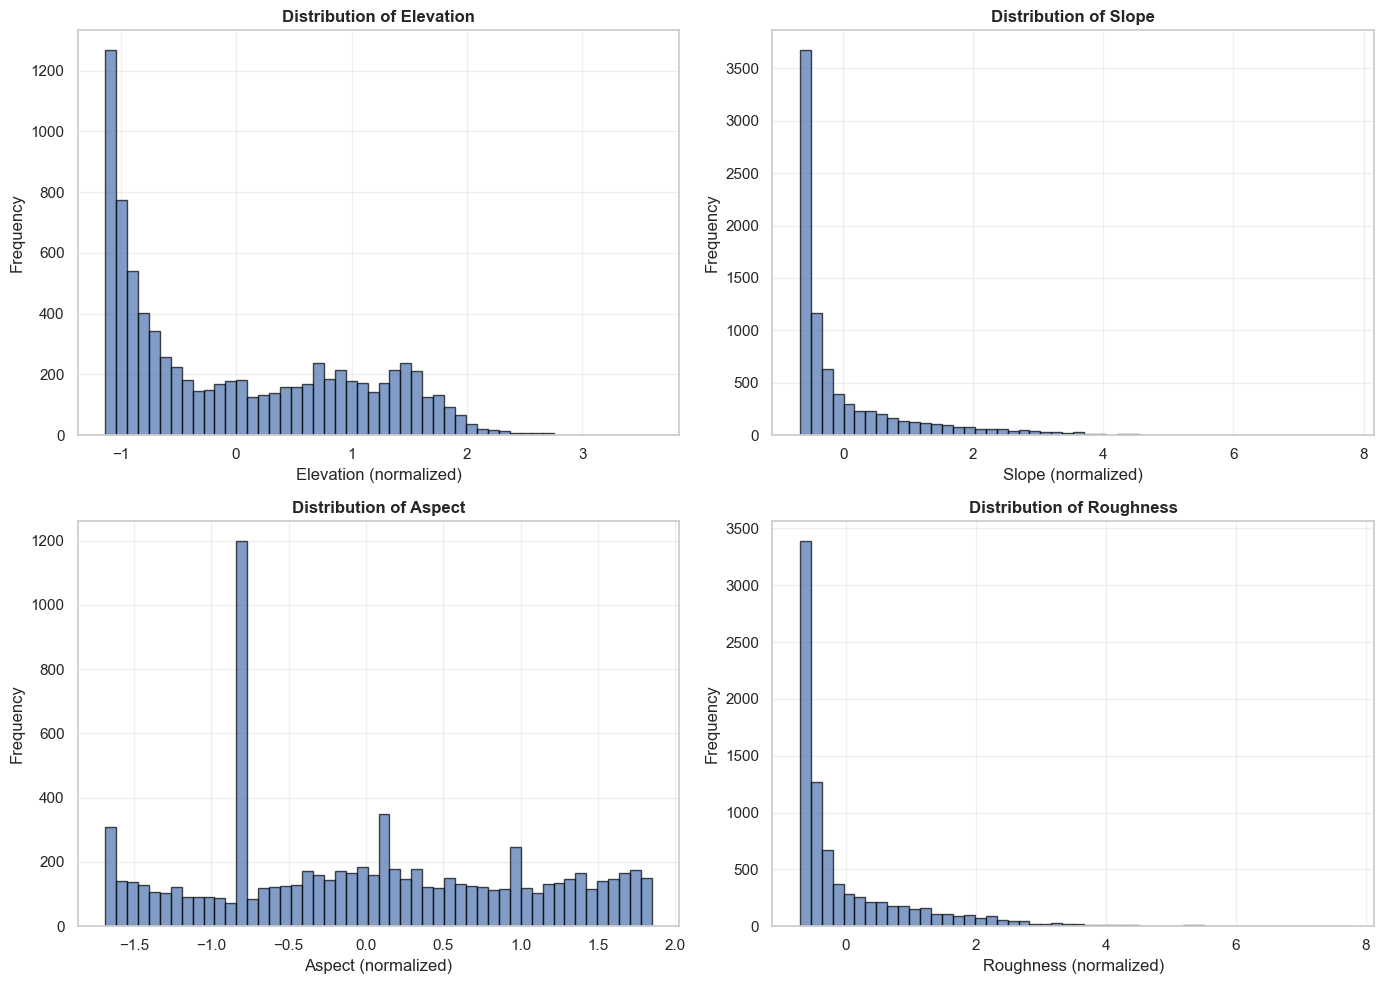

✓ Distribution plots complete!


In [ ]:
if len(fires_raw) > 0:
    # 1. Correlation Heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = fires_raw[terrain_features + ['class']].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=ax, fmt='.3f',
                square=True, linewidths=0.5, vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix (Raw Features)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("Correlation Interpretation:")
    print("  - Values close to ±1 indicate strong linear relationship")
    print("  - Values close to 0 indicate weak linear relationship")
    print(f"\n  Strongest correlations with 'class':")
    class_corr = corr['class'].drop('class').abs().sort_values(ascending=False)
    for feat, val in class_corr.items():
        print(f"    {feat}: {corr['class'][feat]:.3f}")
else:
    print("No data available for correlation analysis")

### 4.3 Bivariate Terrain Relationships

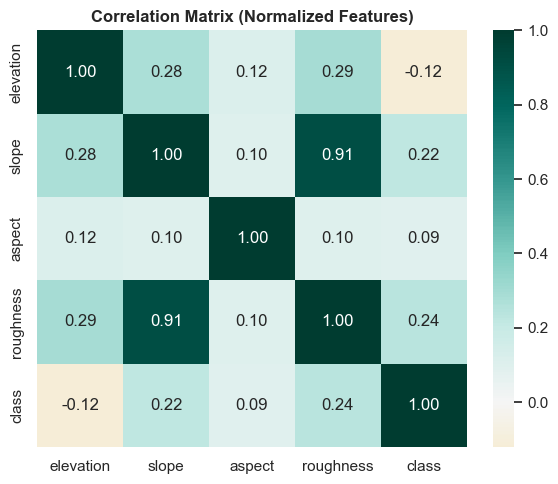

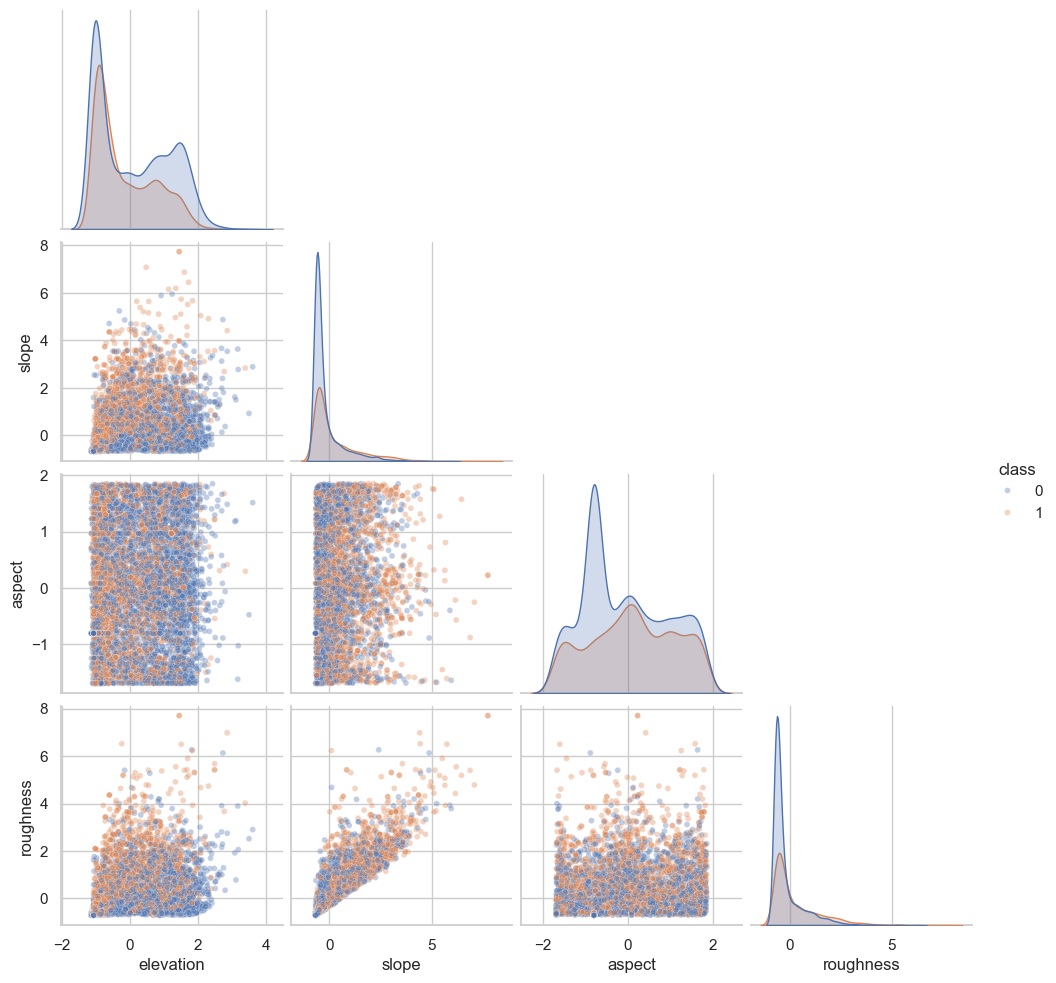

In [ ]:
if len(fires_raw) > 0:
    # 2. Pairwise Scatter Plots with class coloring
    g = sns.pairplot(
        fires_raw[['class'] + terrain_features],
        hue='class',
        diag_kind='kde',
        corner=True,
        plot_kws={'alpha': 0.4, 's': 15},
        palette={0: 'blue', 1: 'red'}
    )
    g.fig.suptitle('Pairwise Scatter Plots (Raw Features)', y=1.02, fontweight='bold', fontsize=14)
    plt.show()
    
    print("✓ Pairwise scatter plots complete!")
    print("\nInterpretation:")
    print("  - Diagonal: KDE distribution by class")
    print("  - Off-diagonal: Scatter plots showing feature relationships")
    print("  - Color: Blue=No Fire (0), Red=Fire (1)")
else:
    print("No data available for bivariate analysis")

### 3.4 Fire vs Terrain Relationship (Raw Values)

Compare terrain characteristics between fire and non-fire locations using actual physical values.

FIRE VS TERRAIN ANALYSIS

Fire points: 3285
No-fire points: 4927

Mean Terrain Features by Fire Class:
------------------------------------------------------------
elevation   : Fire= -0.148, No-Fire=  0.098
slope       : Fire=  0.275, No-Fire= -0.183
aspect      : Fire=  0.106, No-Fire= -0.071
roughness   : Fire=  0.292, No-Fire= -0.195


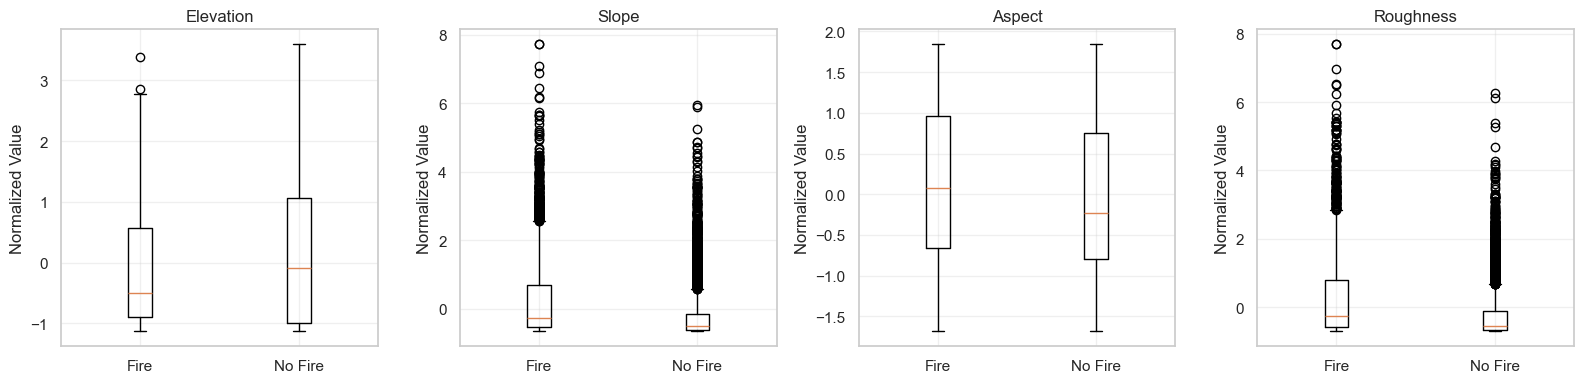


✓ Fire vs terrain analysis complete!


In [ ]:
if len(fires_raw) > 0:
    print("="*60)
    print("FIRE VS TERRAIN ANALYSIS (RAW VALUES)")
    print("="*60)
    
    # Separate fire and no-fire
    fire_data = fires_raw[fires_raw['class'] == 1]
    no_fire_data = fires_raw[fires_raw['class'] == 0]
    
    print(f"\nClass Distribution:")
    print(f"  Fire points (class=1): {len(fire_data)} ({len(fire_data)/len(fires_raw)*100:.1f}%)")
    print(f"  No-fire points (class=0): {len(no_fire_data)} ({len(no_fire_data)/len(fires_raw)*100:.1f}%)")
    
    # Compare statistics
    print("\n" + "-"*60)
    print("Mean Terrain Features by Fire Class (RAW VALUES):")
    print("-"*60)
    print(f"{'Feature':<12} {'Fire Mean':>12} {'No-Fire Mean':>14} {'Difference':>12} {'Unit':<10}")
    print("-"*60)
    
    units = {'elevation': 'm', 'slope': 'degrees', 'aspect': 'degrees', 'roughness': 'index'}
    for feat in terrain_features:
        fire_mean = fire_data[feat].mean()
        no_fire_mean = no_fire_data[feat].mean()
        diff = fire_mean - no_fire_mean
        print(f"{feat:<12} {fire_mean:>12.2f} {no_fire_mean:>14.2f} {diff:>+12.2f} {units[feat]:<10}")
    
    # Boxplot comparison by class
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, feat in enumerate(terrain_features):
        ax = axes[idx]
        data_to_plot = [no_fire_data[feat].dropna(), fire_data[feat].dropna()]
        bp = ax.boxplot(data_to_plot, labels=['No Fire (0)', 'Fire (1)'], patch_artist=True)
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        ax.set_title(f'{feat.capitalize()} by Fire Class', fontweight='bold')
        ax.set_ylabel(f'{feat.capitalize()} ({units[feat]})')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical test (Mann-Whitney U test for non-normal data)
    print("\n" + "-"*60)
    print("Statistical Significance Tests (Mann-Whitney U):")
    print("-"*60)
    for feat in terrain_features:
        stat, p_value = stats.mannwhitneyu(fire_data[feat].dropna(), no_fire_data[feat].dropna())
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"  {feat:<12}: p-value = {p_value:.4e} {significance}")
    print("\n  Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
    
    print("\n✓ Fire vs terrain analysis complete!")
    print("="*60)
else:
    print("No data available for analysis")

---
## Section 4: Data Preprocessing

Based on EDA findings, apply preprocessing steps: remove duplicates, handle outliers, and normalize features.

### 4.1 Check and Remove Duplicates

In [ ]:
print("="*60)
print("CHECKING FOR DUPLICATES")
print("="*60)

# Create working copy for preprocessing
fires_processed = fires_raw.copy()

# Check for duplicate coordinates
coord_cols = ['longitude', 'latitude']
duplicates = fires_processed.duplicated(subset=coord_cols, keep=False)
n_duplicates = duplicates.sum()

print(f"\nDuplicate coordinate pairs: {n_duplicates}")

if n_duplicates > 0:
    print(f"\nRemoving duplicates (keeping first occurrence)...")
    fires_processed = fires_processed.drop_duplicates(subset=coord_cols, keep='first')
    print(f"  Records before: {len(fires_raw)}")
    print(f"  Records after: {len(fires_processed)}")
    print(f"  Removed: {len(fires_raw) - len(fires_processed)}")
else:
    print("  ✓ No duplicates found")

print("\n✓ Duplicate check complete!")
print("="*60)

### 4.2 Handle Outliers (IQR Method)

Use the Interquartile Range (IQR) method to detect and handle outliers. Values beyond 1.5×IQR from Q1/Q3 are considered outliers.

In [ ]:
print("="*60)
print("OUTLIER DETECTION AND HANDLING")
print("="*60)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    return outliers, lower_bound, upper_bound

print("\nOutlier Detection (IQR Method):")
print("-"*60)
print(f"{'Feature':<12} {'Outliers':<10} {'Lower Bound':<15} {'Upper Bound':<15} {'Action':<15}")
print("-"*60)

outlier_summary = {}
for feat in terrain_features:
    outliers, lb, ub = detect_outliers_iqr(fires_processed, feat)
    n_outliers = outliers.sum()
    pct = n_outliers / len(fires_processed) * 100
    outlier_summary[feat] = {'count': n_outliers, 'pct': pct, 'lower': lb, 'upper': ub}
    
    # Decide action based on outlier percentage
    if pct > 5:
        action = "Cap (winsorize)"
    else:
        action = "Keep"
    
    print(f"{feat:<12} {n_outliers:<10} {lb:<15.2f} {ub:<15.2f} {action:<15}")

print("-"*60)

In [ ]:
# Apply winsorization (capping) for features with >5% outliers
print("\nApplying Outlier Treatment (Winsorization):")
print("-"*60)

for feat in terrain_features:
    info = outlier_summary[feat]
    if info['pct'] > 5:
        # Cap outliers at bounds
        original_min = fires_processed[feat].min()
        original_max = fires_processed[feat].max()
        
        fires_processed[feat] = fires_processed[feat].clip(lower=info['lower'], upper=info['upper'])
        
        new_min = fires_processed[feat].min()
        new_max = fires_processed[feat].max()
        
        print(f"  {feat}: Capped to [{info['lower']:.2f}, {info['upper']:.2f}]")
        print(f"    Before: [{original_min:.2f}, {original_max:.2f}]")
        print(f"    After:  [{new_min:.2f}, {new_max:.2f}]")
    else:
        print(f"  {feat}: No treatment needed ({info['pct']:.1f}% outliers)")

print("\n✓ Outlier handling complete!")
print("="*60)

### 4.3 Normalize Features (StandardScaler)

In [ ]:
print("="*60)
print("FEATURE NORMALIZATION")
print("="*60)

# Store original values for reference
fires_before_norm = fires_processed[terrain_features].copy()

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
fires_processed[terrain_features] = scaler.fit_transform(fires_processed[terrain_features])

print(f"\n✓ Normalized {len(terrain_features)} terrain features using StandardScaler")
print(f"  Method: z = (x - μ) / σ")
print(f"  Result: Mean ≈ 0, Std ≈ 1")

print(f"\nNormalization Parameters:")
print("-"*60)
print(f"{'Feature':<12} {'Mean (μ)':<15} {'Std (σ)':<15}")
print("-"*60)
for i, feat in enumerate(terrain_features):
    print(f"{feat:<12} {scaler.mean_[i]:<15.4f} {scaler.scale_[i]:<15.4f}")

print(f"\nPost-Normalization Statistics:")
print("-"*60)
for feat in terrain_features:
    mean = fires_processed[feat].mean()
    std = fires_processed[feat].std()
    print(f"  {feat}: mean={mean:.6f}, std={std:.6f}")

print("\n✓ Normalization complete!")
print("="*60)

### 4.4 Validate Preprocessing Results

In [ ]:
print("="*60)
print("PREPROCESSING VALIDATION")
print("="*60)

# Compare before and after
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feat in enumerate(terrain_features):
    # Before (raw)
    ax1 = axes[0, idx]
    fires_before_norm[feat].hist(bins=40, ax=ax1, alpha=0.7, edgecolor='black', color='steelblue')
    ax1.set_title(f'{feat.capitalize()}\n(Before)', fontweight='bold')
    ax1.set_xlabel('Raw Value')
    if idx == 0:
        ax1.set_ylabel('Frequency')
    
    # After (normalized)
    ax2 = axes[1, idx]
    fires_processed[feat].hist(bins=40, ax=ax2, alpha=0.7, edgecolor='black', color='forestgreen')
    ax2.set_title(f'{feat.capitalize()}\n(After)', fontweight='bold')
    ax2.set_xlabel('Normalized Value')
    if idx == 0:
        ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Summary statistics comparison
print("\nPreprocessing Summary:")
print("-"*60)
print(f"  Initial records (raw): {len(fires_raw)}")
print(f"  After duplicate removal: {len(fires_processed)}")
print(f"  Final records: {len(fires_processed)}")
print(f"\n  Features processed: {terrain_features}")
print(f"  Normalization method: StandardScaler (z-score)")

print("\n✓ Preprocessing validation complete!")
print("="*60)

---
## Section 5: Save Results

Save all processed data and generate summary reports.

In [ ]:
print("="*60)
print("SAVING RESULTS")
print("="*60)

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

# Save fires with elevation features (preprocessed and normalized)
output_path_fires = results_dir / 'fires_with_elevation_features.csv'
fires_processed.to_csv(output_path_fires, index=False)

print(f"\n✓ [PRIMARY OUTPUT] Fires with elevation features saved:")
print(f"  📄 {output_path_fires}")
print(f"  Shape: {fires_processed.shape}")
print(f"  Columns: {list(fires_processed.columns)}")

# Save clipped elevation raster
output_path_raster = results_dir / 'elevation_raster_fires_clipped.tif'
tif_profile = clipped_profile.copy()
tif_profile.update(driver='GTiff')
with rio.open(output_path_raster, 'w', **tif_profile) as dst:
    dst.write(clipped_array)
print(f"\n✓ Clipped elevation raster saved:")
print(f"  📄 {output_path_raster}")

# Generate summary report
summary_path = results_dir / 'elevation_processing_summary.txt'
with open(summary_path, 'w') as f:
    f.write("ELEVATION DATA PROCESSING SUMMARY\n")
    f.write("="*60 + "\n\n")
    
    f.write("Input Data:\n")
    f.write(f"  - GMTED2010 Elevation Raster\n")
    f.write(f"  - Resolution: 15 arc-seconds (~450m)\n")
    f.write(f"  - Original size: {raster_data.shape[1]} x {raster_data.shape[2]} pixels\n")
    f.write(f"  - Fire points: {len(fires_df):,}\n\n")
    
    f.write("Spatial Operations:\n")
    f.write(f"  - Clipped size: {clipped_array.shape[1]} x {clipped_array.shape[2]} pixels\n")
    f.write(f"  - Size reduction: {(1 - (clipped_array.size / raster_data.size)) * 100:.1f}%\n\n")
    
    f.write("Features Computed:\n")
    f.write(f"  - Elevation (m)\n")
    f.write(f"  - Slope (degrees)\n")
    f.write(f"  - Aspect (degrees, 0-360)\n")
    f.write(f"  - Terrain Roughness Index\n\n")
    
    f.write("Preprocessing Steps:\n")
    f.write(f"  1. Duplicate removal: {len(fires_raw) - len(fires_processed)} duplicates removed\n")
    f.write(f"  2. Outlier handling: IQR method (winsorization for >5% outliers)\n")
    f.write(f"  3. Normalization: StandardScaler (z-score)\n\n")
    
    f.write("Final Output:\n")
    f.write(f"  - File: {output_path_fires.name}\n")
    f.write(f"  - Records: {len(fires_processed):,}\n")
    f.write(f"  - Features: {terrain_features}\n")

print(f"\n✓ Summary report saved:")
print(f"  📄 {summary_path}")

print("\n" + "="*60)
print("✓ ALL PROCESSING COMPLETE!")
print("="*60)
print(f"\n🎯 PRIMARY OUTPUT:")
print(f"  → {output_path_fires.name}")
print(f"  → {fires_processed.shape[0]} records × {fires_processed.shape[1]} columns")
print(f"  → longitude, latitude, class + 4 normalized terrain features")
print(f"\n📁 Additional files:")
print(f"  → {output_path_raster.name}")
print(f"  → {summary_path.name}")
print("="*60)

SAVING RESULTS

✓ [PRIMARY OUTPUT] Fires with elevation features saved:
  📄 ..\results\fires_with_elevation_features.csv
  Shape: (8212, 7)
  Columns: ['longitude', 'latitude', 'class', 'elevation', 'slope', 'aspect', 'roughness']

✓ Clipped elevation raster saved:
  📄 ..\results\elevation_raster_fires_clipped.tif

✓ Summary report saved:
  📄 ..\results\elevation_processing_summary.txt

✓ ALL PROCESSING COMPLETE!

🎯 PRIMARY OUTPUT:
  → fires_with_elevation_features.csv
  → 8212 records × 7 columns
  → longitude, latitude, class + 4 normalized terrain features

📁 Additional files:
  → elevation_raster_fires_clipped.tif
  → elevation_processing_summary.txt
